# Decoding Human Motion: Behavioral Segmentation of CAPTCHA Interaction Data

**Team 165:** Cho, Hiura, Kweon, Yu, Zailaa | CSE 6242, Spring 2026

---

## Overview

Modern CAPTCHA systems identify bots by analyzing *how* a user moves the mouse, not just whether they click the right thing. This notebook asks: do different CAPTCHA game types cause people to move differently? If so, the same slow movement might be normal in one game and suspicious in another task context matters for any behavioral classifier.

**Pipeline:**

| Step | What it does |
|---|---|
| 1. Load | Pull 10,000 mouse sessions from the dataset |
| 2. Extract | Compute 6 movement features per session |
| 3. Compare | Check whether game type shifts those features |
| 4. Correlate | Identify redundant features |
| 5. Normalize | Z-score within each game type |
| 6. EDA Summary | Consolidate findings into design decisions |
| 7. Cluster | K-Means on normalized features; PCA for 2-D visualization |
| 8. Profile | Characterize each behavioral group |
| 9. Export | Write 3 JSON files to `dashboard/data/` |

`random_state=42` is set throughout — re-running produces identical results.


In [21]:
from __future__ import annotations
from typing import Any
import gc, warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

print("Imports complete")


Imports complete


In [24]:
HF_TOKEN = os.getenv("HF_TOKEN", "")
REVISION  = "b0daded215cf660365fd9902a4ed9bade3e65fa8"

print("Loading 10,000 sessions from CaptchaSolve30k...")
ds = load_dataset(
    "Capycap-AI/CaptchaSolve30k",
    token=HF_TOKEN,
    revision=REVISION,
    split="train[:20000]",
)
df_raw = ds.to_pandas()

# Filter: require >= 2 trajectory points per session
def _is_valid(ticks):
    if ticks is None:
        return False
    try:
        return len(list(ticks)) >= 2
    except (TypeError, ValueError):
        return False

df = df_raw[df_raw["tickInputs"].apply(_is_valid)].reset_index(drop=True)

print(f"  Loaded:   {len(df_raw):,} sessions")
print(f"  Valid:    {len(df):,} sessions (removed {len(df_raw)-len(df)} with < 2 ticks)")
print(f"\n Dataset schema:")
print(f"  Columns: {list(df.columns)}")
print(f"\n Game type distribution:")
for gt, count in df["gameType"].value_counts().items():
    print(f"  {gt:22s} {count:5,} ({count/len(df)*100:.1f}%)")
print(f"\n Touchscreen sessions: {df['touchscreen'].sum():,} ({df['touchscreen'].mean()*100:.1f}%)")

df.head(3)


Using the latest cached version of the dataset since Capycap-AI/CaptchaSolve30k couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /Users/yulmucho/.cache/huggingface/datasets/Capycap-AI___captcha_solve30k/default/0.0.0/6f1a92bc53612ff3f8595e7ae3817f017a33c269 (last modified on Sat Mar 14 17:10:13 2026).


Loading 10,000 sessions from CaptchaSolve30k...
  Loaded:   20,000 sessions
  Valid:    20,000 sessions (removed 0 with < 2 ticks)

 Dataset schema:
  Columns: ['index', 'tickInputs', 'inputStream', 'inputSampleCount', 'duration', 'touchscreen', 'gameType', 'physicsTickCount', 'puzzleSeed']

 Game type distribution:
  thread-the-needle      7,037 (35.2%)
  polygon-stacking       6,531 (32.7%)
  sheep-herding          6,432 (32.2%)

 Touchscreen sessions: 2,329 (11.6%)


,index,tickInputs,inputStream,inputSampleCount,duration,touchscreen,gameType,physicsTickCount,puzzleSeed
0,2169,"[{'isDown': False, 'sampleIndex': 1, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,2143,10261.0,False,thread-the-needle,2460,716
1,20635,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1184,5597.4,False,thread-the-needle,1341,2152
2,4833,"[{'isDown': False, 'sampleIndex': 6, 'x': 0.0,...",AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA...,1510,7036.7,False,thread-the-needle,1686,846


---
##  Turning Mouse Trails into Numbers

Each raw session is a list of `(x, y, isDown, sampleIndex)` ticks. We deduplicate by `sampleIndex` (the game engine occasionally double-logs) and discard steps faster than 800 px/sample (physically impossible for a human hand).

**The 6 features extracted per session:**

| Feature | What it measures |
|---|---|
| `duration` | Total session time in milliseconds |
| `path_length` | Total cursor distance traveled (px) |
| `speed_mean` | Average step distance (px/sample) |
| `path_efficiency` | Straight-line distance ÷ path length (1.0 = perfectly direct) |
| `pause_rate` | Fraction of steps where speed < 0.5 px/sample (near-stationary) |
| `speed_std` | Variability of speed — captures bursts vs. smooth movement |

These six features capture the main axes of behavioral variation with no trigonometric edge cases.


In [28]:
EPS = 1e-6
MAX_SPEED_PS = 800  # px/sample — filter out teleport glitches

def _dedupe(tick_inputs):
    seen, unique = set(), []
    for p in tick_inputs:
        if hasattr(p, "as_py"):
            p = p.as_py()
        idx = int(p["sampleIndex"])
        if idx not in seen:
            seen.add(idx)
            unique.append(p)
    return unique

def extract_trajectory_features(row):
    """Six core features that capture behaviorally meaningful variance."""
    tick_inputs = row.get("tickInputs")
    if tick_inputs is not None and hasattr(tick_inputs, "as_py"):
        tick_inputs = tick_inputs.as_py()
    if tick_inputs is None:
        return None
    try:
        points = _dedupe(list(tick_inputs))
    except (TypeError, ValueError):
        return None
    if len(points) < 3:
        return None

    coords = np.asarray([(p["x"], p["y"]) for p in points], dtype=float)
    step_d = np.linalg.norm(np.diff(coords, axis=0), axis=1)

    # Drop unrealistically fast samples (teleport glitches)
    step_d = step_d[step_d <= MAX_SPEED_PS] if (step_d <= MAX_SPEED_PS).sum() > 2 else step_d

    path_length    = float(step_d.sum())
    straight_line  = float(np.linalg.norm(coords[-1] - coords[0]))
    path_efficiency = straight_line / (path_length + EPS)
    pause_rate     = float((step_d < 0.5).mean())  # fraction of steps near-stationary

    return {
        "duration":        float(row.get("duration", 0.0)),
        "path_length":     path_length,
        "speed_mean":      float(step_d.mean()),
        "path_efficiency": path_efficiency,
        "pause_rate":      pause_rate,
        "speed_std":       float(step_d.std()),   # variability — bursts vs. smooth
        "game_type":       row.get("gameType"),
        "touchscreen":     bool(row.get("touchscreen", False)),
    }

print("Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)")


Feature extraction defined (6 features: duration, path_length, speed_mean, path_efficiency, pause_rate, speed_std)


In [29]:
features_list, n_errors, first_error = [], 0, None

for i, row in enumerate(df.to_dict(orient="records")):
    if i % 2000 == 0:
        print(f"  Processing... {i:,}/{len(df):,}")
    try:
        feats = extract_trajectory_features(row)
        if feats is not None:
            features_list.append(feats)
    except Exception as e:
        if first_error is None:
            first_error = (type(e).__name__, str(e)[:200])
        n_errors += 1

feat_df = pd.DataFrame(features_list)
gc.collect()

print(f"\n Extracted {feat_df.shape[1]} features from {feat_df.shape[0]:,} sessions")
print(f"   ({n_errors} errors, {len(df) - feat_df.shape[0] - n_errors} filtered for < 3 points)")
if first_error:
    print(f"\nFirst error: {first_error[0]}: {first_error[1]}")

print("\n Feature summary statistics:")
display(feat_df[[
    "duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"
]].describe().round(3))

print(f"\n Path efficiency range: "
      f"{feat_df['path_efficiency'].min():.4f} - {feat_df['path_efficiency'].max():.4f} "
      f"(1.0 = perfectly straight)")


  Processing... 0/20,000
  Processing... 2,000/20,000
  Processing... 4,000/20,000
  Processing... 6,000/20,000
  Processing... 8,000/20,000
  Processing... 10,000/20,000
  Processing... 12,000/20,000
  Processing... 14,000/20,000
  Processing... 16,000/20,000
  Processing... 18,000/20,000

 Extracted 8 features from 20,000 sessions
   (0 errors, 0 filtered for < 3 points)

 Feature summary statistics:


,duration,path_length,speed_mean,path_efficiency,pause_rate,speed_std
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,10728.851,946.896,1.575,0.193,0.486,5.040
std,6417.682,621.013,1.358,0.123,0.211,3.287
min,3502.700,111.300,0.056,0.000,0.035,0.220
25%,6791.175,439.200,0.895,0.100,0.298,3.179
50%,9074.800,775.936,1.316,0.155,0.546,4.245
75%,12150.050,1341.813,1.972,0.265,0.631,5.784
max,59636.000,10485.737,16.745,0.932,0.969,27.808



 Path efficiency range: 0.0001 - 0.9316 (1.0 = perfectly straight)


### Feature summary

- **Speed** varies widely across sessions the distribution has a long right tail.
- **Path efficiency** is low for most sessions; humans naturally take winding routes.
- **Pause rate** varies significantly, hinting at hesitation patterns that differ by task.
- **Duration** spans a wide range driven more by task difficulty than user skill.

Next: check whether these distributions shift depending on which game was played.


---
# Does the Task Change How People Move?

If sheep-herding naturally produces slower, more erratic movement then a slow session in that game is not suspicious. We need to quantify the task effect before grouping users.

1. Per-task mean and standard deviation for all 6 features
2. Four plots: duration, path efficiency, speed distribution, and pause rate by game type


In [30]:
# Task-specific aggregate profiles
profiles = (
    feat_df
    .groupby("game_type", dropna=False)
    .agg(
        n=("game_type", "size"),
        speed_mean=("speed_mean", "mean"), speed_sd=("speed_mean", "std"),
        eff_mean=("path_efficiency", "mean"), eff_sd=("path_efficiency", "std"),
        pause_mean=("pause_rate", "mean"), pause_sd=("pause_rate", "std"),
        dur_mean=("duration", "mean"), dur_sd=("duration", "std"),
    )
    .sort_values("n", ascending=False)
)

print(" Task-Specific Behavioral Profiles:\n")
display(pd.DataFrame({
    "Sessions": profiles["n"],
    "Speed (px/sample)": profiles.apply(lambda r: f"{r.speed_mean:.2f} ± {r.speed_sd:.2f}", axis=1),
    "Path Efficiency": profiles.apply(lambda r: f"{r.eff_mean:.3f} ± {r.eff_sd:.3f}", axis=1),
    "Pause Rate": profiles.apply(lambda r: f"{r.pause_mean:.3f} ± {r.pause_sd:.3f}", axis=1),
    "Duration (ms)": profiles.apply(lambda r: f"{r.dur_mean:.0f} ± {r.dur_sd:.0f}", axis=1),
}))


 Task-Specific Behavioral Profiles:



,Sessions,Speed (px/sample),Path Efficiency,Pause Rate,Duration (ms)
game_type,,,,,
thread-the-needle,7037,1.02 ± 0.59,0.301 ± 0.126,0.579 ± 0.147,7487 ± 4601
polygon-stacking,6531,1.45 ± 0.78,0.173 ± 0.077,0.619 ± 0.088,11485 ± 6443
sheep-herding,6432,2.31 ± 1.96,0.096 ± 0.032,0.248 ± 0.151,13507 ± 6555


### Task profiles

- **Thread-the-needle** :physically constrained path forces high efficiency and low pause rate even for average users.
- **Sheep-herding** : chasing moving targets produces high speed variance and the highest pause rates; erratic movement is normal here.
- **Polygon-stacking** : bursty grab-and-place interaction; both speed and pause rate fall in the middle.

the same raw feature values mean different things depending on the game. Normalization must happen within each task, not globally.


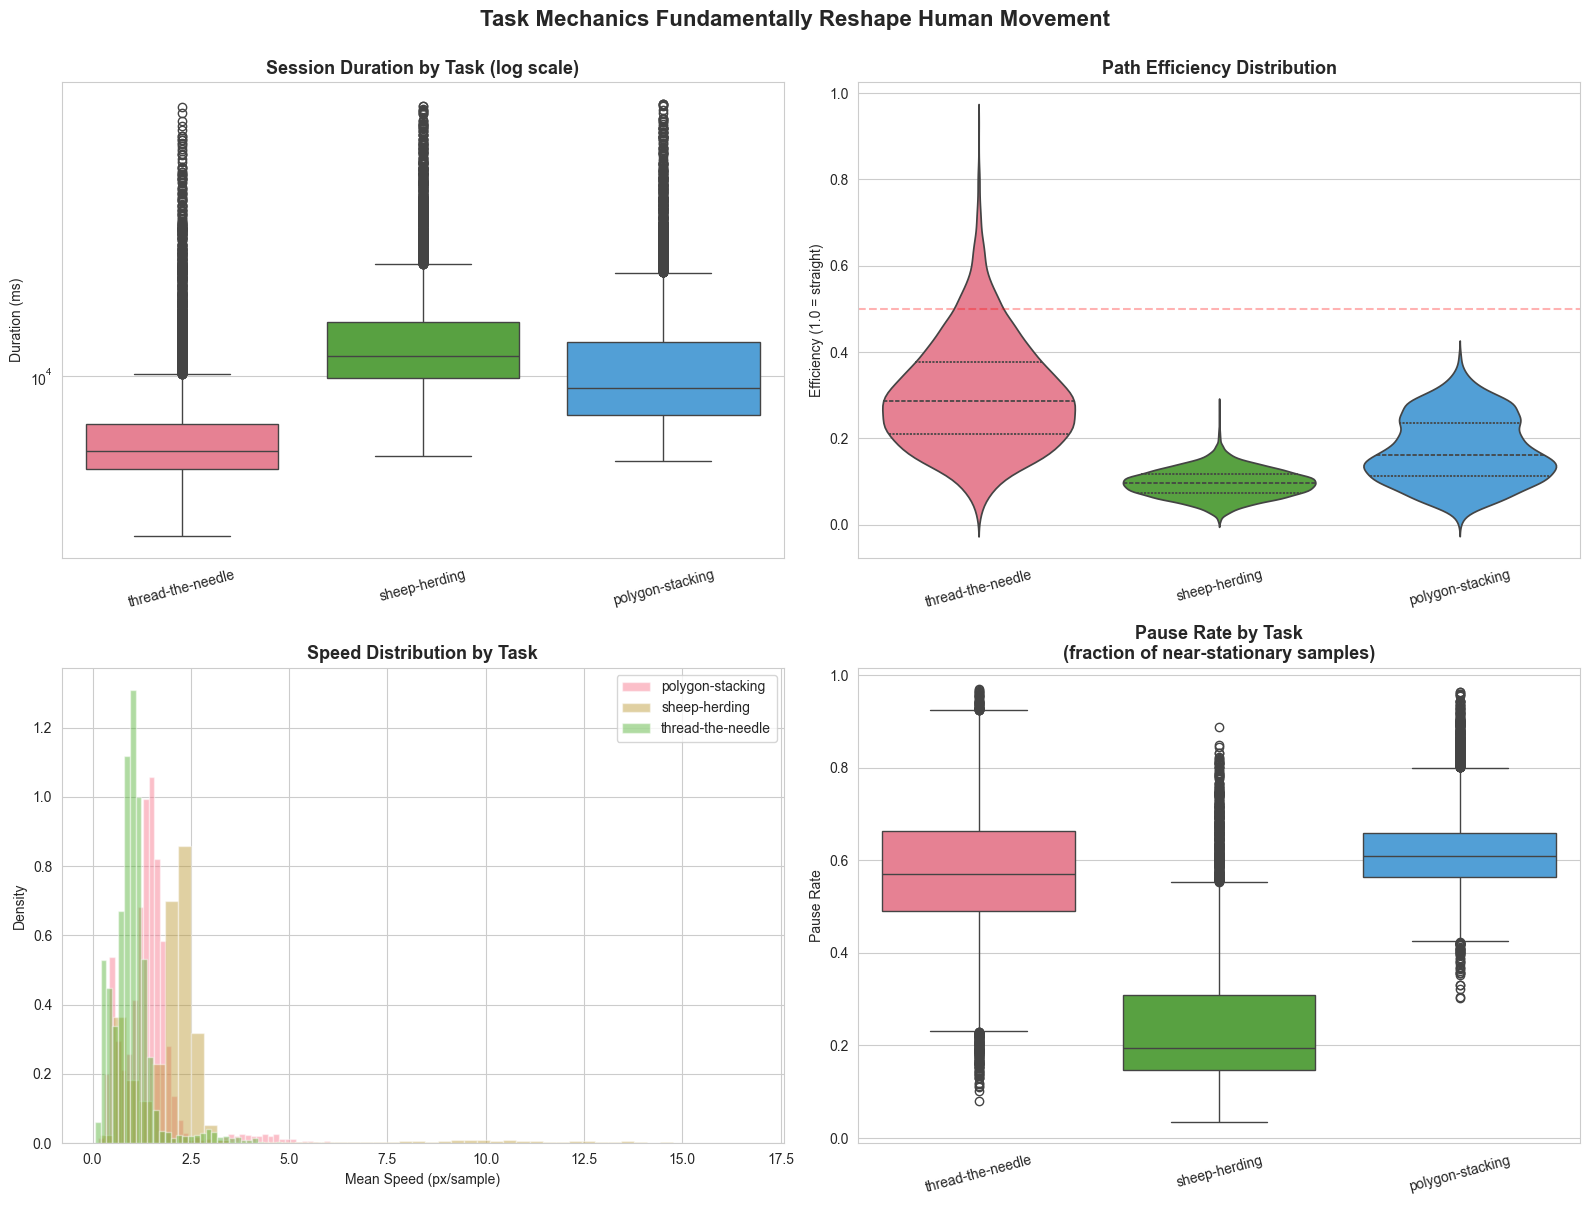

In [31]:
# 2x2 multi-view display
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = sns.color_palette("husl", n_colors=feat_df["game_type"].nunique())

# Top-left: Duration (log scale)
sns.boxplot(data=feat_df, x="game_type", y="duration", palette=colors, ax=axes[0, 0])
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Session Duration by Task (log scale)", fontsize=13, weight="bold")
axes[0, 0].set_xlabel(""); axes[0, 0].set_ylabel("Duration (ms)")
axes[0, 0].tick_params(axis="x", rotation=15)

# Top-right: Path efficiency violin
sns.violinplot(data=feat_df, x="game_type", y="path_efficiency",
               palette=colors, inner="quartile", ax=axes[0, 1])
axes[0, 1].set_title("Path Efficiency Distribution", fontsize=13, weight="bold")
axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("Efficiency (1.0 = straight)")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].axhline(y=0.5, color="red", linestyle="--", alpha=0.3)

# Bottom-left: Speed distributions overlaid
for gt, sub in feat_df.groupby("game_type"):
    axes[1, 0].hist(sub["speed_mean"], bins=50, alpha=0.45, density=True, label=str(gt))
axes[1, 0].set_xlabel("Mean Speed (px/sample)"); axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Speed Distribution by Task", fontsize=13, weight="bold")
axes[1, 0].legend(loc="upper right")

# Bottom-right: Pause rate by task
sns.boxplot(data=feat_df, x="game_type", y="pause_rate", palette=colors, ax=axes[1, 1])
axes[1, 1].set_title("Pause Rate by Task\n(fraction of near-stationary samples)", fontsize=13, weight="bold")
axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("Pause Rate")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.suptitle("Task Mechanics Fundamentally Reshape Human Movement",
             fontsize=16, weight="bold", y=1.00)
plt.tight_layout()
plt.show()


### Reading the plots

- **Duration** :thread-the-needle finishes fastest; sheep-herding runs 2–3× longer. Duration tracks task difficulty more than user skill.
- **Path efficiency** : thread-the-needle occupies a narrow high-efficiency band. An unusually efficient sheep-herding session would stand out as anomalous.
- **Speed** : distributions overlap across tasks; speed alone cannot separate behavioral groups.
- **Pause rate** : highest in sheep-herding (chasing targets), lowest in thread-the-needle (constrained channel). Confirms task-specific normalization is necessary.


---
## Device Type Evaluation

In [37]:
print("Touchscreen vs. Nontouchscreen device proportion:")
display(feat_df['touchscreen'].value_counts(normalize=True))

device_type = (
    feat_df.groupby(['touchscreen','game_type'])
            .agg(
                    n=("game_type", "size"),
                    speed_mean=("speed_mean", "mean"), speed_sd=("speed_mean", "std"),
                    eff_mean=("path_efficiency", "mean"), eff_sd=("path_efficiency", "std"),
                    pause_mean=("pause_rate", "mean"), pause_sd=("pause_rate", "std"),
                    dur_mean=("duration", "mean"), dur_sd=("duration", "std"),
                )
            .sort_values('n')
)

print("\nDevice type and Game type statistics: ")
display(device_type)

Touchscreen vs. Nontouchscreen device proportion:


touchscreen
False    0.88355
True     0.11645
Name: proportion, dtype: float64


Device type and Game type statistics: 


n  speed_mean  speed_sd  eff_mean    eff_sd  \
touchscreen game_type                                                           
True        sheep-herding       743    5.510549  4.266507  0.090263  0.039852   
            polygon-stacking    755    2.705324  1.390940  0.185453  0.082565   
            thread-the-needle   831    1.840799  1.141754  0.323643  0.148626   
False       sheep-herding      5689    1.896419  0.665986  0.097257  0.030757   
            polygon-stacking   5776    1.287237  0.458515  0.171338  0.076104   
            thread-the-needle  6206    0.904814  0.342428  0.297982  0.122297   

                               pause_mean  pause_sd      dur_mean       dur_sd  
touchscreen game_type                                                           
True        sheep-herding        0.316453  0.148091  16152.309287  8819.045582  
            polygon-stacking     0.640074  0.114197  13894.604901  8805.785052  
            thread-the-needle    0.454398  0.196542   8748.013641  6090.828671  
False       sheep-herding        0.239312  0.148793  13161.897627  6115.556852  
            polygon-stacking     0.616808  0.083605  11170.275260  5996.261263  
            thread-the-needle    0.595642  0.129708   7318.446455  4336.492654

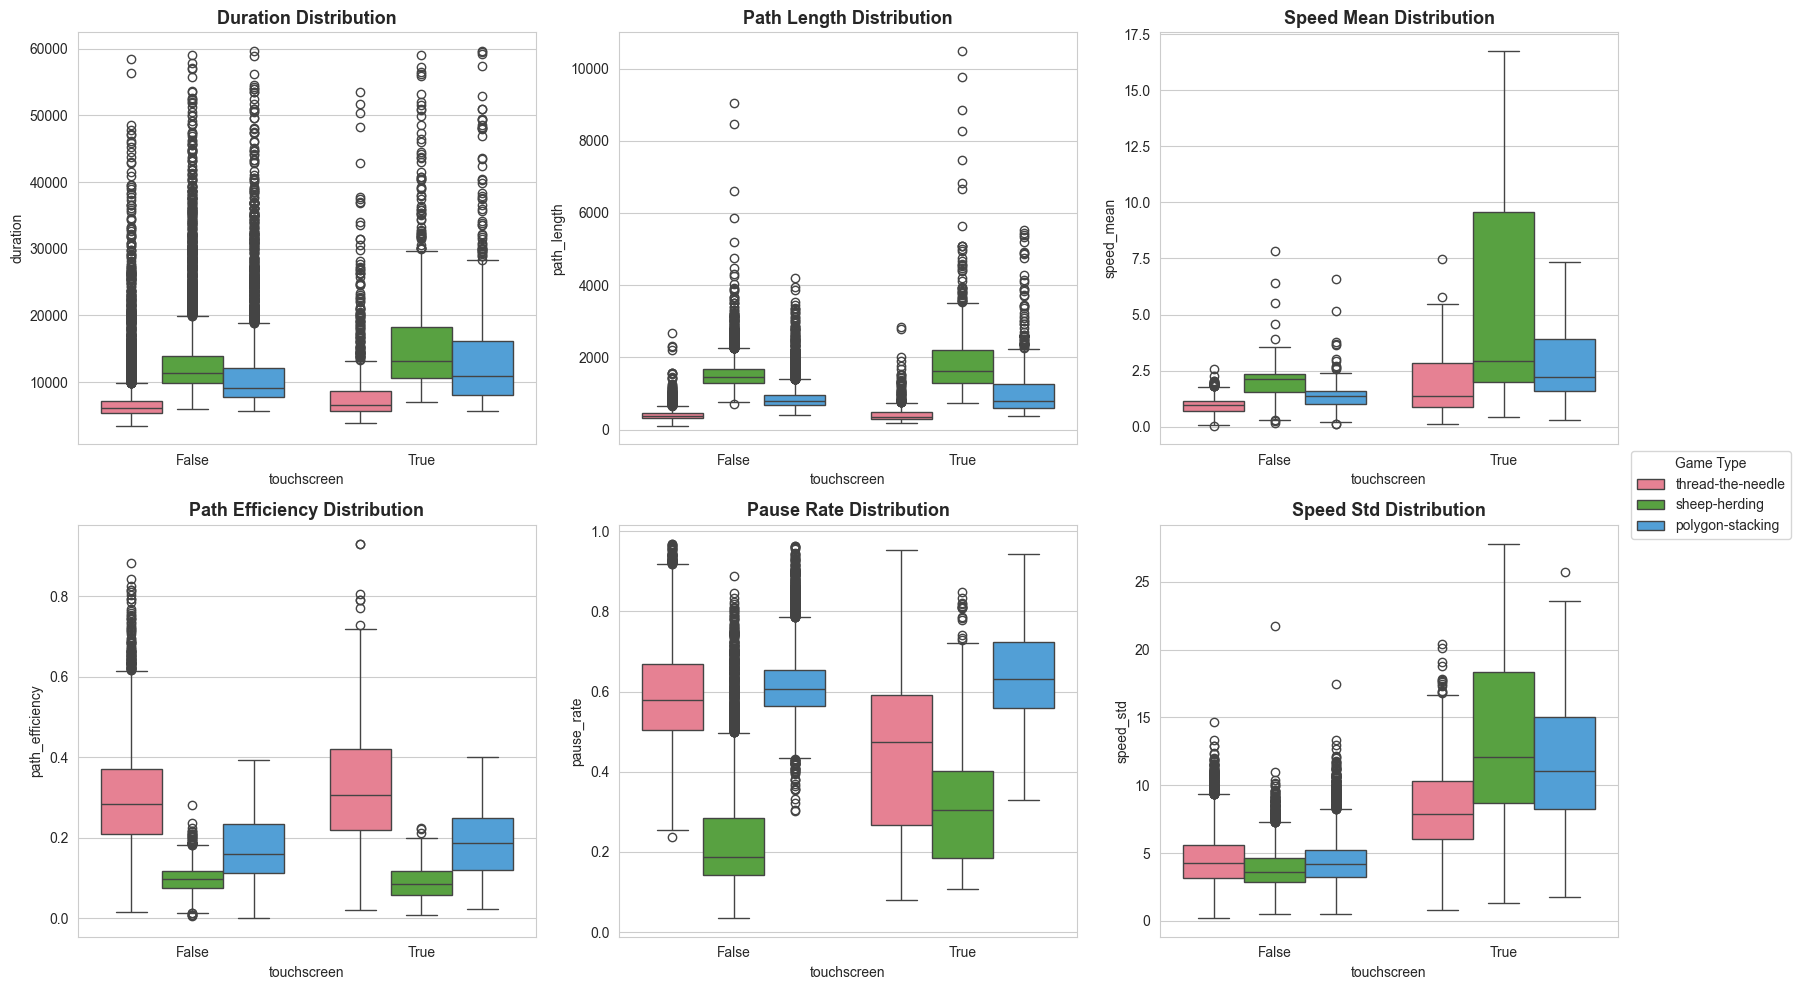

In [36]:
features = ['duration', 'path_length', 'speed_mean', 'path_efficiency', 'pause_rate', 'speed_std']

fig, axes = plt.subplots(2,3, figsize=(18,10))
axes = axes.flatten()

for i,f in enumerate(features):
    sns.boxplot(data=feat_df,
                   x='touchscreen',
                   y=f,
                   hue='game_type',
                   palette=colors,
                   ax=axes[i])
    axes[i].set_title(f"{f.replace('_',' ').title()} Distribution", fontsize=13, weight='bold')
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Game Type", loc="center right")

plt.tight_layout(rect=[0,0,0.91,1])
plt.show()

Based on the distribution charts, overall behavioral patterns remain consistent across device types within each game type. However, the interquartile range across most movement metrics is generally wider among touchscreen users, indicating higher behavioral variability. This may reflect differences in physical interaction constraints, such as reduced pointing precision and increased motor noise associated with direct finger input. In particular, the speed distribution for the sheep-herding task using touchscreen device is much wider in range. 
Given the scope of this project, we aim to determine whether the difference between touchscreen and non-touchscreen session distributions are statistically significant. Since touchscreen sessions represent over 10% of the overall dataset, evaluating the impact is important for deciding whether excluding touchscreen session is appropriate to maintain behavioral consistency in the segmentation analysis. 

---
## Device Type Significance Test

Based on the distribution charts, all behavioral metrics distributions are skewed. This suggests that the Mann-Whitney Significance test is appropriate, as it is a non-parametric method that does not assume normality of the data. 
However, given the very large dataset size, even negiligible behavioral differences may yield statistically significant p-values. To address this, we apply the test by downsampling nontouchscreen sessions to the size of corresponding touchscreen sessions to assess whether the observed differences remain consistently significant. 

In [57]:
from scipy.stats import mannwhitneyu

mw_result = []


for g in feat_df["game_type"].unique(): 
    sub = feat_df[feat_df["game_type"] == g]

    for f in features: 
        touch = sub.loc[sub["touchscreen"], f]
        nontouch = sub.loc[~sub["touchscreen"], f].sample(len(touch), random_state=42)
    
        stat, p = mannwhitneyu(touch, nontouch)
    
        mw_result.append((g, f, p, p<0.05))

mw_df = (pd.DataFrame(mw_result, columns=["game_type", "feature", "p-value", "statistical_significance"])
            .sort_values(by=["game_type", "feature"])
            .reset_index(drop=True)
        )
print("Mann-Whitney U test result:")
display(mw_df)


Mann-Whitney U test result:


,game_type,feature,p-value,statistical_significance
0,polygon-stacking,duration,5.092613e-14,True
1,polygon-stacking,path_efficiency,2.842094e-05,True
2,polygon-stacking,path_length,8.274206e-01,False
3,polygon-stacking,pause_rate,1.363308e-06,True
4,polygon-stacking,speed_mean,1.675400e-108,True
5,polygon-stacking,speed_std,2.464785e-204,True
6,sheep-herding,duration,3.855676e-19,True
7,sheep-herding,path_efficiency,2.843580e-07,True
8,sheep-herding,path_length,3.816975e-15,True
9,sheep-herding,pause_rate,1.183033e-33,True


The Mann-Whitney U test result was conducted within each game type to control for task-specific behavioral differences. The results show that most p-values are very small. Using a significance level of 0.05, only *path_length* in the polygon-stacking taks had p-value greater than 0.05, indicating that differences in these features across devicetypes are not statistically significant. 
This suggests that touchscreen and nontouchscreen sessions exhibit systematically different behavioral patterns within game types. 

---
## Are Any Features Redundant?

Correlated features push PCA in the same direction and can drown out weaker signals. We check which of our 6 features are strongly related and whether those relationships hold across game types additional evidence for within-task normalization.


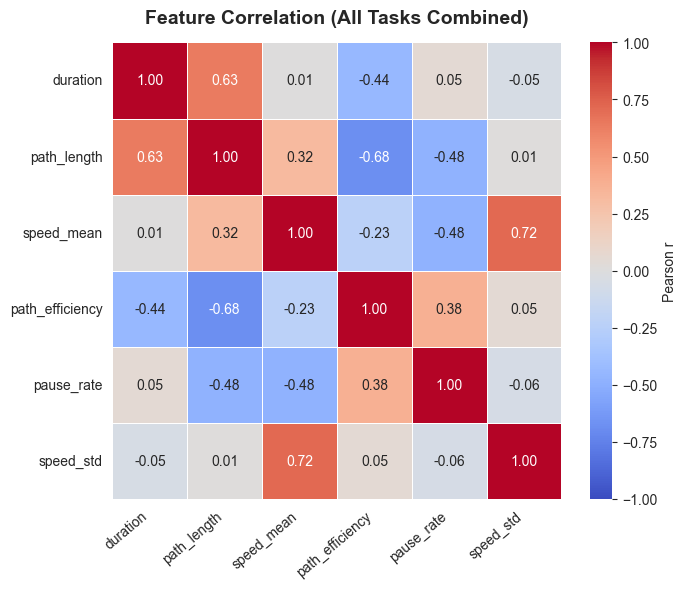


 Strongly correlated pairs (|r| > 0.50):


,f1,f2,r
0,speed_mean,speed_std,0.717972
1,path_length,path_efficiency,-0.682807
2,duration,path_length,0.634399


In [7]:
# Global correlation heatmap across the 6 core features
heat_features = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]
corr = feat_df[heat_features].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            cbar_kws={"label": "Pearson r"})
plt.title("Feature Correlation (All Tasks Combined)", fontsize=14, weight="bold", pad=14)
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# Extract strongly correlated pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
strong_pairs = (
    upper.stack().rename("r").reset_index()
    .rename(columns={"level_0": "f1", "level_1": "f2"})
    .query("r.abs() > 0.5")
    .sort_values("r", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("\n Strongly correlated pairs (|r| > 0.50):")
display(strong_pairs)


In [8]:
# Task-segmented correlation table
pair_cols = list(zip(strong_pairs["f1"].head(5), strong_pairs["f2"].head(5)))

seg_data = []
for g in feat_df["game_type"].dropna().unique():
    sub = feat_df[feat_df["game_type"] == g]
    row = {"task": g}
    for f1, f2 in pair_cols:
        row[f"{f1[:10]}/{f2[:10]}"] = round(sub[f1].corr(sub[f2]), 3)
    seg_data.append(row)

seg_corr_df = pd.DataFrame(seg_data).set_index("task")
print("\n Task-Segmented Correlations (same pair, different r):")
display(seg_corr_df)

print("\n Correlation magnitudes shift dramatically across tasks.")
print(" Example: If speed_mean x speed_std has r=0.85 in sheep-herding but")
print(" r=0.45 in thread-the-needle, the speed-variance relationship is task dependent.")



 Task-Segmented Correlations (same pair, different r):


,speed_mean/speed_std,path_lengt/path_effic,duration/path_lengt
task,,,
thread-the-needle,0.750,-0.551,0.594
sheep-herding,0.869,-0.574,0.525
polygon-stacking,0.826,-0.502,0.687



 Correlation magnitudes shift dramatically across tasks.
 Example: If speed_mean x speed_std has r=0.85 in sheep-herding but
 r=0.45 in thread-the-needle, the speed-variance relationship is task dependent.


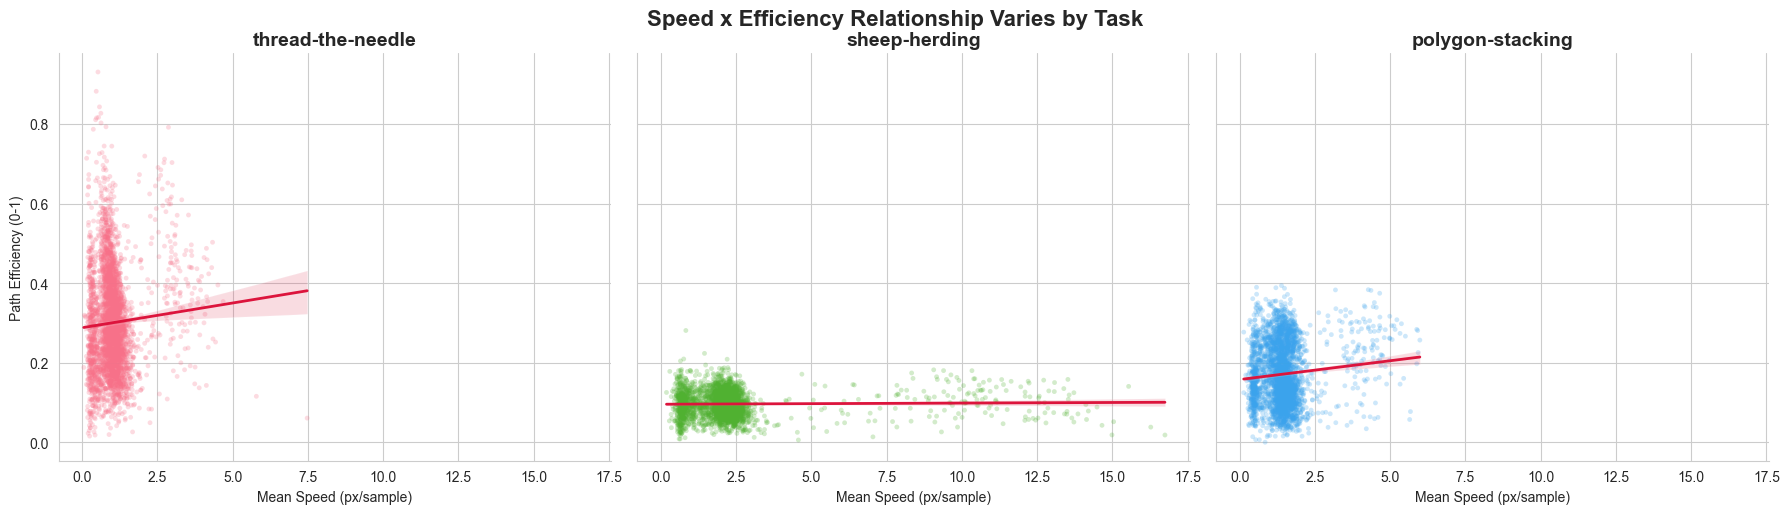


 Observations:
 Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)
Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)
Conclusion: A single global regression would be misleading


In [9]:
# Faceted scatter: speed vs path efficiency
g = sns.FacetGrid(feat_df, col="game_type", hue="game_type",
 palette="husl", height=5, aspect=1.2, col_wrap=3)
g.map(sns.scatterplot, "speed_mean", "path_efficiency", alpha=0.25, s=12, edgecolor='none')
g.map(sns.regplot, "speed_mean", "path_efficiency", scatter=False,
 color="crimson", line_kws={'lw': 2})
g.set_axis_labels("Mean Speed (px/sample)", "Path Efficiency (0-1)")
g.set_titles(col_template="{col_name}", size=14, weight='bold')
g.fig.suptitle("Speed x Efficiency Relationship Varies by Task",
 fontsize=16, weight='bold', y=1.02)
plt.show()

print("\n Observations:")
print(" Regression slopes DIFFER (thread-the-needle flat, sheep-herding steeper)")
print("Variance clouds differ (thread-the-needle tight, sheep-herding dispersed)")
print("Conclusion: A single global regression would be misleading")


---
# Normalizing 

Z-score each feature within its game type (subtract group mean, divide by group std). This removes the task-level baseline shift so the clustering step compares users on their relative behavior within each game, not their absolute values across games.

Features with near-zero variance within a group are set to 0.


In [10]:
CLUSTER_FEATURES = ["duration", "path_length", "speed_mean", "path_efficiency", "pause_rate", "speed_std"]

print(f"Clustering on {len(CLUSTER_FEATURES)} features: {CLUSTER_FEATURES}")

# Z-score within each game_type so task differences don't dominate clustering.
# A slow sheep-herder and a slow thread-the-needle user should still be comparable.
feat_df_norm = feat_df.copy()
for col in CLUSTER_FEATURES:
    for gt, grp_idx in feat_df_norm.groupby("game_type").groups.items():
        vals = feat_df_norm.loc[grp_idx, col].astype(float)
        mu, sigma = vals.mean(), vals.std()
        feat_df_norm.loc[grp_idx, col] = (vals - mu) / sigma if sigma > 1e-8 else 0.0

feat_df_norm[CLUSTER_FEATURES] = feat_df_norm[CLUSTER_FEATURES].fillna(0.0)
z_cols = CLUSTER_FEATURES
print("Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.")


Clustering on 6 features: ['duration', 'path_length', 'speed_mean', 'path_efficiency', 'pause_rate', 'speed_std']
Task-relative z-scoring complete — each feature is mean=0, std=1 within each game type.


---

| Finding | Design decision |
|---|---|
| Game type shifts all 6 features significantly | Normalize within each game type |
| Speed and path_length are correlated | PCA will collapse redundancy before clustering |
| Pause rate differs sharply across tasks | Strong justification for within-task normalization |
| Number of behavioral groups is unknown | K-Means with elbow plot to select *k* |
| Need 2-D coordinates for the scatter plot | Use PCA components 1 & 2 directly |


In [11]:
# Create synthesis table
synthesis_data = [
    {
        "Finding": "Game type drives 2x variance in duration & efficiency",
        "Design Decision": "Task-specific z-score normalization before clustering",
        "Section": "3.1 Feature Engineering"
    },
    {
        "Finding": "Sheep-herding shows highest pause rate (natural human noise)",
        "Design Decision": "Per-task normalization ensures fair cross-task comparison",
        "Section": "3.2 Clustering"
    },
    {
        "Finding": "Thread-the-needle forces high efficiency (constrained path)",
        "Design Decision": "Even small efficiency deviations are behaviorally meaningful",
        "Section": "3.2 Clustering"
    },
    {
        "Finding": "Speed x efficiency correlation shifts by task (r: 0.45→0.85)",
        "Design Decision": "Within-task z-scoring removes task-level baseline confound",
        "Section": "3.1 Feature Engineering"
    },
    {
        "Finding": "6 features capture most behavioral variance (PCA elbow at 2–3 components)",
        "Design Decision": "Simple feature set reduces noise and improves K-Means stability",
        "Section": "3.1 Feature Engineering"
    },
]

synthesis_df = pd.DataFrame(synthesis_data)
print("\n EDA Findings → Design Decisions:\n")
display(synthesis_df)



 EDA Findings → Design Decisions:



,Finding,Design Decision,Section
0,Game type drives 2x variance in duration & eff...,Task-specific z-score normalization before clu...,3.1 Feature Engineering
1,Sheep-herding shows highest pause rate (natura...,Per-task normalization ensures fair cross-task...,3.2 Clustering
2,Thread-the-needle forces high efficiency (cons...,Even small efficiency deviations are behaviora...,3.2 Clustering
3,Speed x efficiency correlation shifts by task ...,Within-task z-scoring removes task-level basel...,3.1 Feature Engineering
4,6 features capture most behavioral variance (P...,Simple feature set reduces noise and improves ...,3.1 Feature Engineering


---
## Compare Clustering Models

To determine the most appropriate clustering structure for the data, we compare KMeans, Gaussian Mixture, and DBSCAN using normalized feature data. Model performance is primarily compared using the silhouette score. Additional supporting metrics such as the Davies-Bouldin, BIC, and AIC are compared to determine the overall best performance. 

- **Sihouette score**: Measures how well each point fits within assigned cluster compared to other clusters. It evaluates the tighteness of clusters and larger separation between cluster. Sihouette score close to 1 indicates perfect clustering while values near 0 indicate overlapping clusters. Negative values indicate potential miscalssification. 
- **Davies-Bouldin index**: Measures how much clusters are similar to each other by comparing the average intra-cluster spread with the distance between clusters. Lower davies-bouldin index is often better.
- **BIC**: Bayesian Information Criterion is used for probablilistic models like GMM, and it measures how well the mdoel explains the data while penalizing increased model complexity. **AIC** (Akaike Information Criterion) is similar to BIC but imposes a weaker penalty on model complexity. When both AIC and BIC decreases, it suggests the model is improving. If AIC decreases while BIC increases, this may imply model is overfit due to excessive model complexity.
  

In [12]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score


X = feat_df_norm[z_cols].values
print("==="*30)
print("Running Kmeans...")
print("==="*30)

kmeans_results = []
# ===================== Kmeans ========================= # 
K_RANGE = range(2,9)
for k in K_RANGE: 
    km = KMeans(n_clusters=k, random_state= 42, n_init=10)
    km_labels = km.fit_predict(X)
    kmeans_results.append({"model": "kmeans", 
                    "k": k, 
                    "silhouette_score": silhouette_score(X, km_labels),
                    "davies_bouldin": davies_bouldin_score(X, km_labels),
                    "inertia": km.inertia_})   
    
print("Run Complete. Kmeans results: \n")
kmeans_df = pd.DataFrame(kmeans_results)
display(pd.DataFrame(kmeans_results))


print("\n"+"==="*30)
print("Running Gaussian Mixtures...")
print("==="*30)

# ==================== Gaussian ======================== # 
gm_results = []
N_COMPONENTS = range(2,9)
for n in N_COMPONENTS: 
    gm = GaussianMixture(n_components = n, covariance_type ='full',random_state = 42)
    gm_labels = gm.fit_predict(X)
    gm_results.append({"model": "gaussian_mixture", 
                    "n_components": n, 
                    "silhouette_score": silhouette_score(X, gm_labels),
                    "BIC": gm.bic(X),
                    "AIC": gm.aic(X)})
    
print("Run Complete. Gaussian Mixtures results: \n")
gm_df = pd.DataFrame(gm_results)
display(pd.DataFrame(gm_results))




print("\n"+"==="*30)
print("Running DBSCAN...")
print("==="*30)

# ===================== DBSCAN ===+===================== # 
db_results = []
EPS = [0.3, 0.5, 1, 2, 3]
for e in EPS: 
    db = DBSCAN(eps=e, min_samples=20)
    db_labels = db.fit_predict(X)
    db_results.append({"model": "dbscan", 
                    "eps": e,
                    "n_clusters": len(set(db_labels)),
                    "silhouette_score": silhouette_score(X, db_labels),
                    "davies_bouldin": davies_bouldin_score(X, db_labels)})


print("Run Complete. DBSCAN results: \n")
db_df = pd.DataFrame(db_results)
display(pd.DataFrame(db_results))
    


Running Kmeans...
Run Complete. Kmeans results: 



,model,k,silhouette_score,davies_bouldin,inertia
0,kmeans,2,0.562170,0.795272,47433.969300
1,kmeans,3,0.448727,1.101616,36103.092947
2,kmeans,4,0.241025,1.212255,29839.856035
3,kmeans,5,0.247071,1.145653,26146.606553
4,kmeans,6,0.247109,1.174821,23745.917537
5,kmeans,7,0.241944,1.143911,21635.542378
6,kmeans,8,0.250501,1.097807,19904.756567



Running Gaussian Mixtures...
Run Complete. Gaussian Mixtures results: 



,model,n_components,silhouette_score,BIC,AIC
0,gaussian_mixture,2,0.359466,112300.312191,111903.743471
1,gaussian_mixture,3,0.272409,100123.795575,99525.337324
2,gaussian_mixture,4,0.159983,96332.467753,95532.119972
3,gaussian_mixture,5,0.154739,92406.987088,91404.749776
4,gaussian_mixture,6,0.021313,86558.890983,85354.764141
5,gaussian_mixture,7,0.034441,83940.777319,82534.760946
6,gaussian_mixture,8,0.030879,83185.349764,81577.443861



Running DBSCAN...
Run Complete. DBSCAN results: 



,model,eps,n_clusters,silhouette_score,davies_bouldin
0,dbscan,0.3,4,-0.327087,2.699702
1,dbscan,0.5,3,0.063341,2.267522
2,dbscan,1.0,3,0.511169,1.790305
3,dbscan,2.0,2,0.708872,0.898120
4,dbscan,3.0,2,0.775662,0.635691


Kmeans results show that the silhouette score is higehst when k = 2. The Davies Bouldin index is also at its lowest at this point, indicating the clusters are most compact and well-separated when partitioned into two clusters.

Gaussian Mixture Model results generally show lower silhouette scores compared to Kmeans, suggesting weaker geometric separation between clusters. However, the silhouette score is still highest with 2 components. Both BIC and AIC score decrease as the number of components increases.  This suggests that the probabilistic model achieves better fit with increased complexity, but it may lead to over segmentation of the data.

DBSCAN model results show the highest silhouette_score when the number of clusters = 2 and eps = 3. The score is much higher than other two models with lower davies_bouldin index. However, the epsilon value is quite large, suggesting that the underlying cluster structure may be broad and potentially includes hidden layers that can be uncovered after dimensionality reduction using PCA. 

Overall, the most appropriate number of clusters using the normalized feature data is 2. 


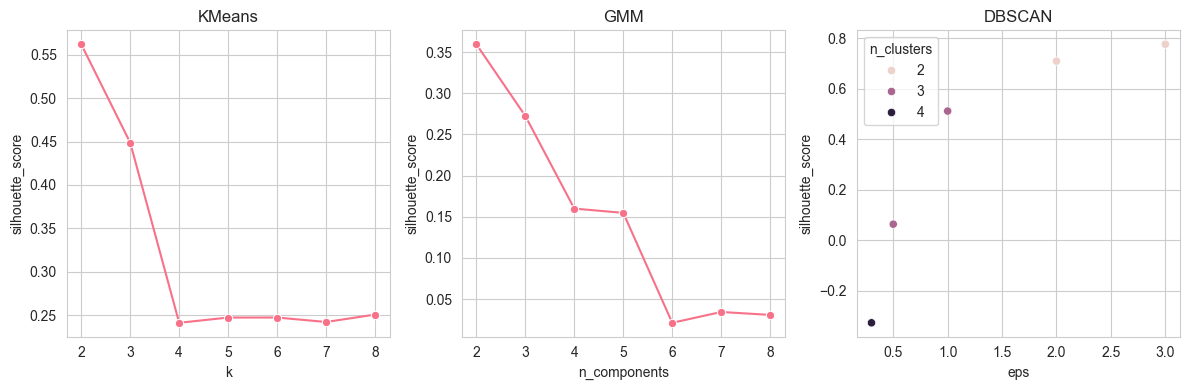

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.lineplot(data=kmeans_df, x="k", y="silhouette_score", marker="o", ax=axes[0])
sns.lineplot(data=gm_df, x="n_components", y="silhouette_score", marker="o", ax=axes[1])
sns.scatterplot(data=db_df, x="eps", y="silhouette_score", hue="n_clusters", sizes="n_clusters", marker="o", ax=axes[2])

axes[0].set_title("KMeans")
axes[1].set_title("GMM")
axes[2].set_title("DBSCAN")

plt.tight_layout(); plt.show()

The comparison graph clearly shows that the silhouette score is highest when the number of clusters is 2 across all three models. The silhouette score tends to drop substantially with 4 and above cluster numbers. Notably, the DBSCAN plot shows that a three cluster solution still achieves a reasonably strong silhouette score when using a moderate epsilon value of 1. This again suggests the presence of potential substructrure within the two primary clusters. 

Next is to compare the model performance using PCA reduced data. 

Principal components with corresponding explained variance: 
PC1: 0.37
PC2: 0.30
PC3: 0.17
PC4: 0.09

Running Kmeans...
Run Complete. Kmeans results: 



,model,k,silhouette_score,davies_bouldin,inertia
0,kmeans,2,0.390109,1.328842,44153.598479
1,kmeans,3,0.457638,1.034877,32486.260202
2,kmeans,4,0.260385,1.138486,26326.766531
3,kmeans,5,0.268978,1.061459,22585.624708
4,kmeans,6,0.250373,1.152648,20537.533203
5,kmeans,7,0.254885,1.095902,18611.911607
6,kmeans,8,0.264702,1.069275,17141.089063



Running Gaussian Mixtures...
Run Complete. Gaussian Mixtures results: 



,model,n_components,silhouette_score,BIC,AIC
0,gaussian_mixture,2,0.336925,109451.207220,109242.107349
1,gaussian_mixture,3,0.346783,101083.297121,100766.042145
2,gaussian_mixture,4,0.151771,99253.614064,98828.203982
3,gaussian_mixture,5,0.171333,98095.017916,97561.452728
4,gaussian_mixture,6,0.137990,97091.460307,96449.740014
5,gaussian_mixture,7,0.146837,96739.165199,95989.289801
6,gaussian_mixture,8,0.156598,96180.714131,95322.683627



Running DBSCAN...
Run Complete. DBSCAN results: 



,model,eps,n_clusters,silhouette_score,davies_bouldin
0,dbscan,0.2,7,-0.431662,2.134425
1,dbscan,0.3,2,0.094733,2.819279
2,dbscan,0.5,2,0.376426,2.386519
3,dbscan,0.8,3,0.526958,1.733718
4,dbscan,1.0,3,0.564298,1.533322



Comparison Plot...


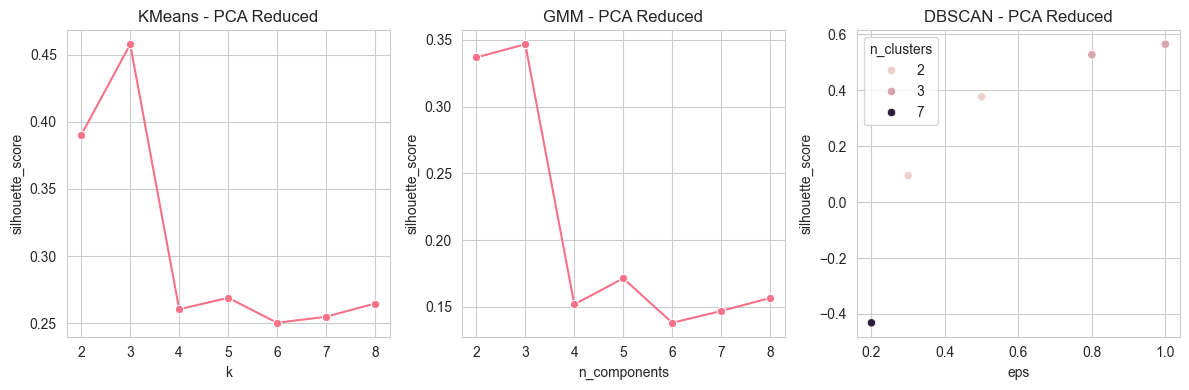

In [14]:

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X)

print("Principal components with corresponding explained variance: ")
explained_variance_ratio = pca.explained_variance_ratio_
for indx, evr in enumerate(explained_variance_ratio):
    print(f"PC{indx+1}: {evr:.2f}")
    
print()
print("==="*30)
print("Running Kmeans...")
print("==="*30)

kmeans_pca_results = []
# ===================== Kmeans ========================= # 
K_RANGE = range(2,9)
for k in K_RANGE: 
    km = KMeans(n_clusters=k, random_state= 42, n_init=10)
    km_labels = km.fit_predict(X_pca)
    kmeans_pca_results.append({"model": "kmeans", 
                    "k": k, 
                    "silhouette_score": silhouette_score(X_pca, km_labels),
                    "davies_bouldin": davies_bouldin_score(X_pca, km_labels),
                    "inertia": km.inertia_})   
    
print("Run Complete. Kmeans results: \n")
kmeans_df_pca = pd.DataFrame(kmeans_pca_results)
display(kmeans_df_pca)


print("\n"+"==="*30)
print("Running Gaussian Mixtures...")
print("==="*30)

# ==================== Gaussian ======================== # 
gm_pc_results = []
N_COMPONENTS = range(2,9)
for n in N_COMPONENTS: 
    gm = GaussianMixture(n_components = n, covariance_type ='full',random_state = 42)
    gm_labels = gm.fit_predict(X_pca)
    gm_pc_results.append({"model": "gaussian_mixture", 
                    "n_components": n, 
                    "silhouette_score": silhouette_score(X_pca, gm_labels),
                    "BIC": gm.bic(X_pca),
                    "AIC": gm.aic(X_pca)})
    
print("Run Complete. Gaussian Mixtures results: \n")
gm_df_pca = pd.DataFrame(gm_pc_results)
display(gm_df_pca)




print("\n"+"==="*30)
print("Running DBSCAN...")
print("==="*30)

# ===================== DBSCAN ===+===================== # 
db_pca_results = []
EPS = [0.2, 0.3, 0.5, 0.8, 1]
for e in EPS: 
    db = DBSCAN(eps=e, min_samples=20)
    db_labels = db.fit_predict(X_pca)
    db_pca_results.append({"model": "dbscan", 
                    "eps": e,
                    "n_clusters": len(set(db_labels)),
                    "silhouette_score": silhouette_score(X_pca, db_labels),
                    "davies_bouldin": davies_bouldin_score(X_pca, db_labels)})


print("Run Complete. DBSCAN results: \n")
db_df_pca = pd.DataFrame(db_pca_results)
display(db_df_pca)

print("\nComparison Plot...")

fig, axes = plt.subplots(1, 3, figsize=(12,4))

sns.lineplot(data=kmeans_df_pca, x="k", y="silhouette_score", marker="o", ax=axes[0])
sns.lineplot(data=gm_df_pca, x="n_components", y="silhouette_score", marker="o", ax=axes[1])
sns.scatterplot(data=db_df_pca, x="eps", y="silhouette_score", hue="n_clusters", sizes="n_clusters", marker="o", ax=axes[2])

axes[0].set_title("KMeans - PCA Reduced")
axes[1].set_title("GMM - PCA Reduced")
axes[2].set_title("DBSCAN - PCA Reduced")

plt.tight_layout(); plt.show()


The data is reduced to 4 Principal components which explain 90% of the total variance. Using the PCA reduced data, highest silhouette score is achieved with number of clusters is 3. While the DBSCAN show the highest silhouette score and helped confirm macro cluster structure, KMeans clustering was ultimately selected due to greater interpretability and stability for behavioral segmentation. 

### KMeans clustering

Applying KMeans algorithm to the PCA reduced data with the best number of K (K = 3) determined above. After we apply cluster name based on behavioral segmentation. 

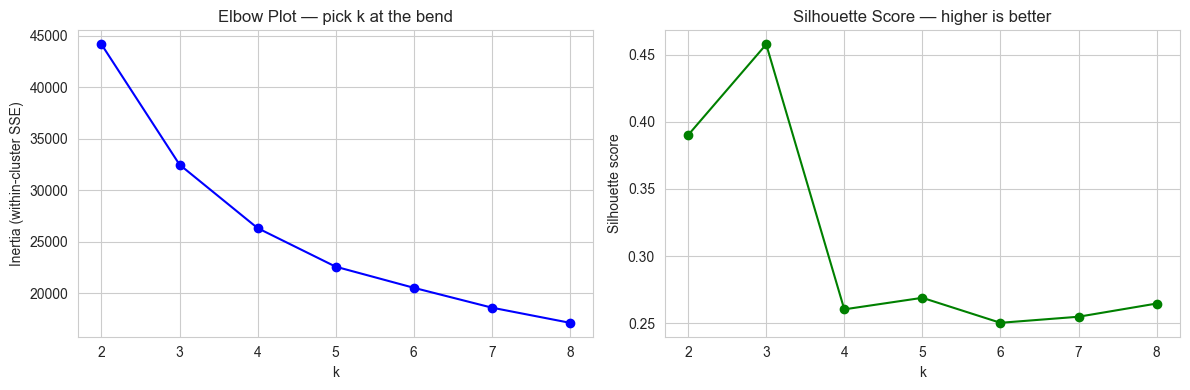


Best k by silhouette: 3  (silhouette=0.458)

Final K-Means (k=3): silhouette=0.458, Davies-Bouldin=1.035
cluster
0    8260
1     471
2    1269

Cluster profiles:


,duration,path_length,speed_mean,path_efficiency,pause_rate,speed_std
cluster,,,,,,
0,9018.745339,864.439945,1.411656,0.201708,0.470879,4.500431
1,9298.319958,827.724599,5.765021,0.248375,0.349428,15.819249
2,22351.924980,1514.989623,1.100661,0.122991,0.633695,4.721899



Cluster names:
  0: Moderate-Balanced-Fluid  (n=8,260)
  1: Fast-Direct-Fluid  (n=471)
  2: Slow-Circuitous-Hesitant  (n=1,269)


In [15]:
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, "b-o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Plot — pick k at the bend")

axes[1].plot(list(K_RANGE), sil_scores, "g-o")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Score — higher is better")
plt.tight_layout(); plt.show()

best_k = int(list(K_RANGE)[int(np.argmax(sil_scores))])
print(f"\nBest k by silhouette: {best_k}  (silhouette={max(sil_scores):.3f})")

K = best_k
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
feat_df["cluster"] = km_final.fit_predict(X_pca)

sil  = silhouette_score(X_pca, feat_df["cluster"])
dbi  = davies_bouldin_score(X_pca, feat_df["cluster"])
print(f"\nFinal K-Means (k={K}): silhouette={sil:.3f}, Davies-Bouldin={dbi:.3f}")
print(feat_df["cluster"].value_counts().sort_index().to_string())

cluster_profiles = feat_df.groupby("cluster")[z_cols].mean()
print("\nCluster profiles:")
display(cluster_profiles)

speed_q3 = cluster_profiles["speed_mean"].quantile(0.75)
speed_q1 = cluster_profiles["speed_mean"].quantile(0.25)
path_q3 = cluster_profiles["path_efficiency"].quantile(0.75)
path_q1 = cluster_profiles["path_efficiency"].quantile(0.25)
pause_q3 = cluster_profiles["pause_rate"].quantile(0.75)

def _name_cluster(row):
    if row["speed_mean"] >= speed_q3: 
        speed = "Fast"
    elif row["speed_mean"] <= speed_q1: 
        speed = "Slow"
    else: 
        speed = "Moderate" 


    if row["path_efficiency"] >= path_q3: 
        eff = "Direct"
    elif row["path_efficiency"] <= path_q1:
        eff = "Circuitous"
    else:
        eff = "Balanced"

    if row["pause_rate"] >= pause_q3: 
        pauses = "Hesitant"
    else: 
        pauses = "Fluid"

    return f"{speed}-{eff}-{pauses}"

cluster_names = {int(cid): _name_cluster(row) for cid, row in cluster_profiles.iterrows()}
feat_df["cluster_name"] = feat_df["cluster"].map(cluster_names)
print("\nCluster names:")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  {cid}: {name}  (n={n:,})")


### Cluster results

The elbow and silhouette plots above indicate the optimal *k*. The final K-Means assigns every session to exactly one cluster — no noise labels, no ambiguity. Cluster names are auto-generated from the relative position of each cluster's feature quantiles. 


In [16]:
# Profile each cluster — mean of the 6 core features per group
profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_profiles_df = (
    feat_df.groupby("cluster")[profile_cols]
    .mean()
    .round(3)
)

print("Cluster profiles (mean feature values):")
display(cluster_profiles_df)
print("\nCluster names (from K-Means cell):")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  Cluster {cid}: {name}  ({n:,} sessions)")

Cluster profiles (mean feature values):


,speed_mean,path_efficiency,pause_rate,speed_std,duration,path_length
cluster,,,,,,
0,1.412,0.202,0.471,4.500,9018.745,864.440
1,5.765,0.248,0.349,15.819,9298.320,827.725
2,1.101,0.123,0.634,4.722,22351.925,1514.990



Cluster names (from K-Means cell):
  Cluster 0: Moderate-Balanced-Fluid  (8,260 sessions)
  Cluster 1: Fast-Direct-Fluid  (471 sessions)
  Cluster 2: Slow-Circuitous-Hesitant  (1,269 sessions)



Cluster names (from K-Means cell):
  Cluster 0: Moderate-Balanced-Fluid  (8,260 sessions)
  Cluster 1: Fast-Direct-Fluid  (471 sessions)
  Cluster 2: Slow-Circuitous-Hesitant  (1,269 sessions)



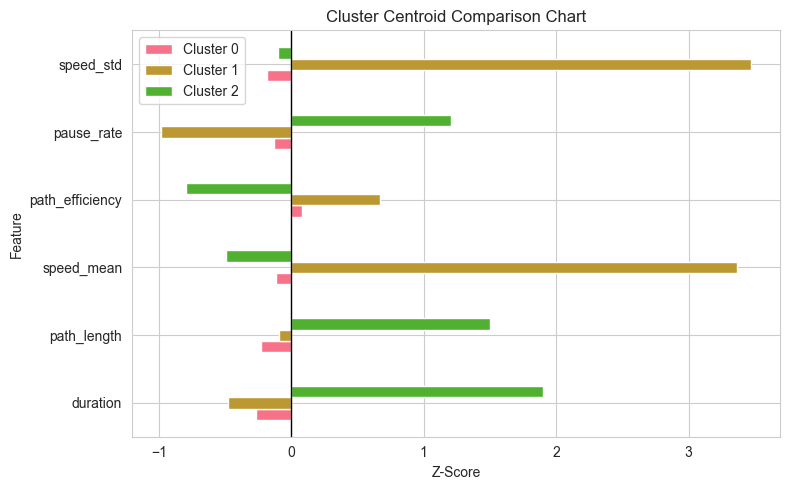

In [17]:
centroids_original = pca.inverse_transform(km_final.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=z_cols,
    index=[f"Cluster {i}" for i in range(K)]
)

print("\nCluster names (from K-Means cell):")
for cid, name in cluster_names.items():
    n = (feat_df["cluster"] == cid).sum()
    print(f"  Cluster {cid}: {name}  ({n:,} sessions)")

    
print()
centroids_df.T.plot(kind="barh", figsize=(8,5))
plt.title("Cluster Centroid Comparison Chart")
plt.xlabel("Z-Score")
plt.ylabel("Feature")
plt.axvline(0, color="black", linestyle="-", linewidth=1)
plt.tight_layout()
plt.show()

The Cluster Centroid Comparison Chart is provided to show how the three groups differ across the feature metrics. Consistent with its label, the Cluster 1 (Fast-Direct-Fluid) shows the highest speed mean, short duration, and low pause rate. Cluster 2 (Slow-Circuitous-Hesitant) shows the longest duration, the greatest path length, and negative path efficiency - reflecting slower and less efficient behavior. Cluster 0 group has centroid values close to 0 across most features, indicating that the group represents the baseline behavioral pattern. 

---

PCA components 1 and 2 (computed in Step 7) serve directly as the x/y axes. Sessions that behaved similarly appear close together; sessions that behaved differently appear far apart. Each dot is colored by its K-Means cluster label.


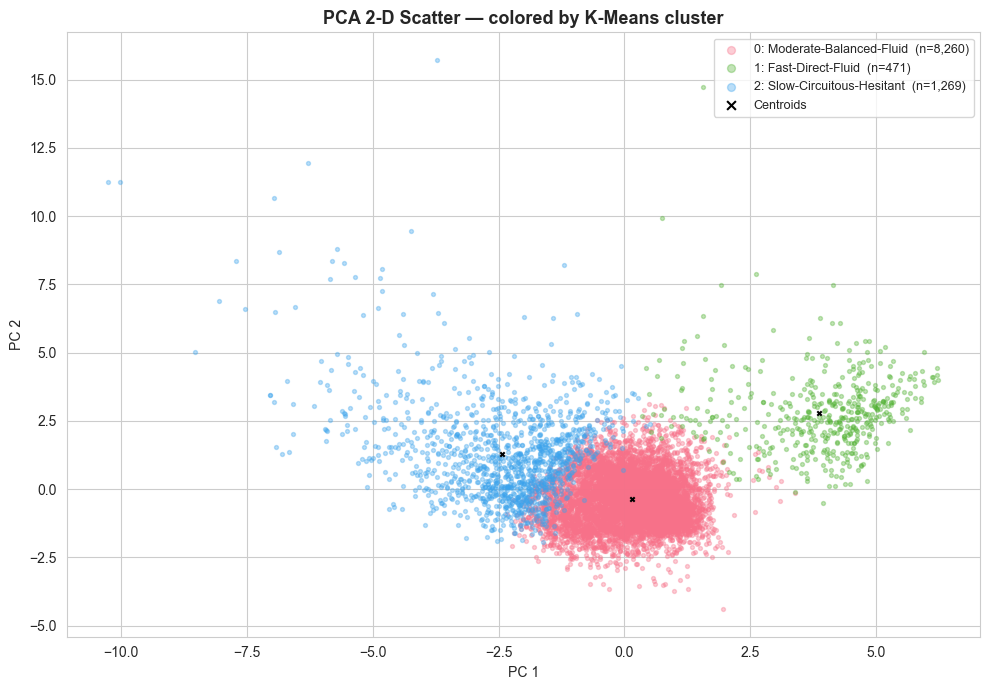

Scatter plot uses feat_df['pca_x'] and feat_df['pca_y'] — already computed, no extra library.


In [18]:
feat_df["pca_x"] = X_pca[:,0]
feat_df["pca_y"] = X_pca[:,1]


fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("husl", n_colors=K)

for cid in sorted(feat_df["cluster"].unique()):
    m = feat_df["cluster"] == cid
    ax.scatter(
        feat_df.loc[m, "pca_x"],
        feat_df.loc[m, "pca_y"],
        c=[palette[cid]], s=8, alpha=0.35,
        label=f"{cid}: {cluster_names.get(cid, '')}  (n={m.sum():,})",
    )

centroids_pca = km_final.cluster_centers_

ax.scatter(centroids_pca[:,0], centroids_pca[:,1], c="black", s = 10, marker="x", edgecolor="white", label="Centroids")

ax.set_title("PCA 2-D Scatter — colored by K-Means cluster", fontsize=13, weight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.legend(loc="best", markerscale=2, framealpha=0.8, fontsize=9)
plt.tight_layout()
plt.show()
print("Scatter plot uses feat_df['pca_x'] and feat_df['pca_y'] — already computed, no extra library.")


---
## Step 9: Export

Write the three output files that the dashboard reads. All files go to `dashboard/data/` so re-running this notebook automatically updates the dashboard.


| File | Contents |
|---|---|
| `scatter_points.json` | One record per session: PCA x/y, cluster label, game type, and feature values for tooltips |
| `cluster_profiles.json` | Per-cluster mean of each feature, normalized 0–1 for radar charts |
| `cluster_meta.json` | Cluster id, name, size, and color hex for the frontend legend |


In [19]:
import json, os

# Write directly into dashboard/data/ so the backend serves them immediately.
# Path is relative to notebook/ directory (where this notebook runs from).
OUTPUT_DIR = os.path.join("..", "dashboard", "data")
os.makedirs(OUTPUT_DIR, exist_ok=True)

scatter = feat_df[[
    "pca_x", "pca_y", "cluster", "cluster_name",
    "game_type", "speed_mean", "path_efficiency", "pause_rate", "duration",
]].copy()
scatter["cluster"] = scatter["cluster"].astype(int)
scatter.to_json(f"{OUTPUT_DIR}/scatter_points.json", orient="records", indent=2)
print(f"scatter_points.json  — {len(scatter):,} rows")


profile_cols = ["speed_mean", "path_efficiency", "pause_rate", "speed_std", "duration", "path_length"]
cluster_means = (
    feat_df.groupby(["cluster", "cluster_name"])[profile_cols]
    .mean()
    .reset_index()
)
for col in profile_cols:
    lo, hi = cluster_means[col].min(), cluster_means[col].max()
    cluster_means[f"{col}_norm"] = (cluster_means[col] - lo) / (hi - lo + 1e-9)

cluster_means["cluster"] = cluster_means["cluster"].astype(int)
cluster_means.to_json(f"{OUTPUT_DIR}/cluster_profiles.json", orient="records", indent=2)
print(f"cluster_profiles.json — {len(cluster_means)} clusters")

palette_hex = sns.color_palette("husl", n_colors=K).as_hex()
cluster_meta = [
    {
        "id": int(cid),
        "name": cluster_names.get(cid, f"Cluster {cid}"),
        "size": int((feat_df["cluster"] == cid).sum()),
        "color": palette_hex[cid],
    }
    for cid in sorted(feat_df["cluster"].unique())
]
with open(f"{OUTPUT_DIR}/cluster_meta.json", "w") as f:
    json.dump(cluster_meta, f, indent=2)
print(f"cluster_meta.json    — {len(cluster_meta)} clusters")
print(f"\nAll files written to: {os.path.abspath(OUTPUT_DIR)}/")


scatter_points.json  — 10,000 rows
cluster_profiles.json — 3 clusters
cluster_meta.json    — 3 clusters

All files written to: /Users/yulmucho/Desktop/OMSA/SP26/CS6242/CSE6242-Captcha/dashboard/data/
